# PREEMI filtered look at the data

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

PATH = "../data/preemi-30apr2021.dta"


## Cleaning data

### Drop columns


In [2]:
df = pd.read_stata(PATH)

df[df == ""] = np.nan

columns = list(df)

# Unique columns
df = df.drop(columns=["protocolid", "personid", "pr_id", "ch_id", "mt_id"])

# Event status
df = df.drop(columns=[c for c in columns if "eventstatus_e" in c])

# Versions
df = df.drop(columns=[c for c in columns if "versionname_e" in c])

# Constant or almost unique
df = df.drop(columns=["haemounava_e1"])
df = df.drop(columns=["checklist_e1"])
df = df.drop(columns=["matstata_e2"])

# Remove columns with high NaNs
N = df.shape[0]
for col in columns:
    if col not in df: continue
    n = df[df[col].isnull()].shape[0]
    if n/N > 0.5:
        df = df.drop(columns=[col])

In [3]:
# Remove redundant _e
import collections
red_cols = collections.defaultdict(list)
for c in list(df.columns):
    x = c.split("_")
    if len(x[-1]) == 2 and x[-1][0] == "e":
        red_cols["_".join(x[:-1])] += ["_".join(x)]

def get_to_drop(v):
    b = -1
    best = None
    for x in v:
        if int(x[-1]) > b:
            b = int(x[-1])
            best = x
    return [x for x in v if x != best]

for k,v in red_cols.items():
    v = get_to_drop(v)
    #df = df.drop(columns=v)

df = df.drop(columns = ["compperson_e5"])

In [4]:
# Minor cleans

df.loc[df["facid_e5"] == "FO3", "facid_e5"] = "F03"
df.loc[df["facid_e5"] == "FO2", "facid_e5"] = "F02"

In [5]:
# Remove dirty variables

df = df.drop(columns=["BWDQ_cat", "birthweightcat1", "gestagecat2", "gestagecat1"])


# Newly realised redundant
df = df.drop(columns = ["facid_e5"])

In [6]:
# Clean data type

def datatype_cleaner(df, col):
    df_ = df.copy()
    df_ = df_[df_[col].notnull()]
    N = df_.shape[0]
    df_["numnew"] = pd.to_numeric(df_[col], errors="coerce")
    df_["datnew"] = pd.to_datetime(df_[col], errors="coerce")
    if df_[df_["numnew"].notnull()].shape[0]/N > 0.8:
        df[col] = pd.to_numeric(df[col])
        return df
    if df_[df_["datnew"].notnull()].shape[0]/N > 0.8:
        df[col] = pd.to_datetime(df[col], errors="coerce")
        df.loc[df[col] < pd.Timestamp(1910,1,1)] = np.nan
        return df
    return df

for col in columns:
    if col not in df: continue
    df = datatype_cleaner(df, col)
    

In [7]:
df.loc[df["matage"] > 60, "matage"] = np.nan
df.loc[df["eduyrs_e1"] > 15, "eduyrs_e1"] = 15
df.loc[df["matwei_e1"] > 200, "matwei_e1"] = np.nan
df.loc[df["babwght_e2"] > 8000, "babwght_e2"] = np.nan

In [8]:
# Filtered based on Kati and Albert's

In [9]:
outcomes = {
    "Pregnancy Outcome": ["fetneo_e2", "outcome", "vitalstatus7", "vitalstatus28", "still",
                          "vitalstatus", "livebirth", "died", "pr_outcome"],
    "Early Neonatal Death": ["infsta_e3"],
    "Late Neonatal Death": ["infsta_e4"],
    "Pre-term Delivery": ["babterm_e2", "preterm"],
    "Birthweight Determined": ["bwdat"]
}

gestation = {
    "Gestation": ["g_age", "gestage"],
    "Expected Due Date": ["edd_e1", "estedd_e1"],
    "Last Menstrual Period": ["mensdate_e1"],
    "Delivery Date": ["delidate1_e1", "motconpl_e2"],
    "Method of Determining Gestation": ["gestmethod"]
}

counfounders = {
    "Maternal Age": ["matage", "age_cat", "matagecat", "dob_day"],
    "School Level": ["schlev_e1"],
    "Years of Education": ["eduyrs_e1"],
    "Parity": ["parity_lbsb", "parity_cat", "parity"], # Number of viable births
    "BMI": ["mathei_e1", "matwei_e1"],
    "Antenatal Visits": ["antcarfreq_e2", "anc_visit"],
    "Delivery By": ["delivby_e2"],
    "Delivery Place": ["delivwhr_e2", "delivfac_e2", "deplace"],
    "Mode of Delivery": ["mod_e2", "detype"],
    "Baby Sex": ["babysex_e2", "sex"],
    "Multiple Birth": ["multbirth_e2", "multiple"]
}

neonatal_tx = {
    "Neonatal Antibiotics": ["neotreant_2"],
    "CPAP": ["neotrecpap_e2"],
    "Oxygen": ["neotreoxy_e2"]
}

interventions = {
    "Antenatal Visits": ["antcarfreq_e2"],
    "Dexamethasone": ["mattredex_e2"],
    "Kangaroo Mother Care Skin to Skin": ["NEOTREKMC_E2_C3"],
    "Cord care Chlorhexidine": ["NEOTREMCC_E2_C3"],
    "Gravida": ["gravida_e1"], # Number of pregnancies (remove)? Counfounder
    "Neonatal Abx": ["NEOTREANT_E2_C3"],
    "Bag and Maks Resuscitation": ["BABRESBM_E2_C3"]
}

all_variables = dict((k,v) for d in [outcomes, gestation, counfounders, mat_exposures] for k,v in d.items())

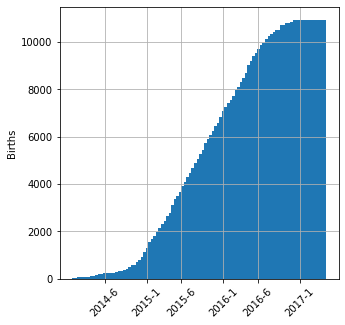

In [62]:
import datetime
from matplotlib.dates import date2num, num2date
import numpy as np


def outcomes_by_date(ax, df, date_col = "mensdate_e1", out_col = "outcome"):    
    df = df[(df[date_col].notnull()) & (df[out_col].notnull())]
    df = df[[date_col, out_col]]
    outs = list(set(df[out_col]))
    outs_counts = {}
    for o in outs:
        outs_counts[o] = df[df[out_col] == o].shape[0]
    outs = sorted(outs_counts.items(), key=lambda x: -x[1])
    outs = [x[0] for x in outs]
    x = np.array([date2num(x) for x in list(pd.to_datetime(df[date_col]))])
    y = np.array(list(df[out_col]))
    idxs = np.argsort(x)
    x = x[idxs]
    y = y[idxs]
    axis = [datetime.date(int(d.split("-")[0]), int(d.split("-")[1]), int(d.split("-")[2])) for d in ["2014-06-15", "2015-01-01", "2015-06-15", "2016-01-01", "2016-06-15", "2017-01-01"]]
    ax.hist(x, bins=100, cumulative=True)
    ax.set_xticks([date2num(d) for d in axis])
    xticks = ax.get_xticks()
    ax.set_xticklabels(["{0}-{1}".format(d.year, d.month) for d in num2date(xticks)], rotation=45)
    ax.set_ylabel("Births")
    ax.grid()
    
fig, axs = plt.subplots(1,1, figsize=(5,5))
ax = axs
outcomes_by_date(ax, df)



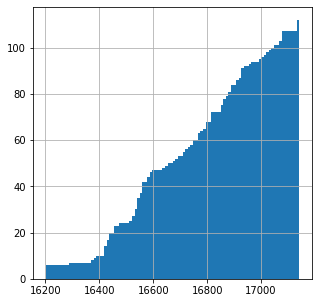

In [71]:
def deaths_by_date(ax, df, date_col = "mensdate_e1", out_col = "infsta_e3"):    
    df = df[(df[date_col].notnull()) & (df[out_col].notnull())]
    df = df[[date_col, out_col]]
    outs = list(set(df[out_col]))
    outs_counts = {}
    for o in outs:
        outs_counts[o] = df[df[out_col] == o].shape[0]
    outs = sorted(outs_counts.items(), key=lambda x: -x[1])
    outs = [x[0] for x in outs]
    x = np.array([date2num(x) for x in list(pd.to_datetime(df[date_col]))])
    y = np.array(list(df[out_col]))
    idxs = np.argsort(x)
    x = x[idxs]
    y = y[idxs]
    x = x[y == "Dead"]
    axis = [datetime.date(int(d.split("-")[0]), int(d.split("-")[1]), int(d.split("-")[2])) for d in ["2014-06-15", "2015-01-01", "2015-06-15", "2016-01-01", "2016-06-15", "2017-01-01"]]
    ax.hist(x, bins=100, cumulative=True)
    #ax.set_xticks([date2num(d) for d in axis])
    #xticks = ax.get_xticks()
    #ax.set_xticklabels(["{0}-{1}".format(d.year, d.month) for d in num2date(xticks)], rotation=45)
    #ax.set_ylabel("Births")
    ax.grid()
    
fig, axs = plt.subplots(1,1, figsize=(5,5))
ax = axs
deaths_by_date(ax, df)

In [65]:
df["infsta_e4"].value_counts()

Alive    10602
Dead        22
Name: infsta_e4, dtype: int64

In [ ]:
df["infsta_e3"]

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:
set(df["gestmethod"])

In [ ]:
df